In [32]:
# set path 
path ="/glade/work/alancelin/PlaSim-emulator-diagnosis/"
import sys
import os
# sys.path.append(path)
path_v2 = "/glade/work/alancelin/PanguWeather/v2.0"
# sys.path.append(current_path)
# make this path, the main path for running the scripts
os.chdir(path_v2)

import xarray as xr
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import trange
# from src.score import *
from collections import OrderedDict
# from src.utils import 
sns.set_style('darkgrid')
sns.set_context('notebook')

import torch
from utils.YParams import YParams

# Nvidia tests

In [2]:
import torch
torch.cuda.is_available()

False

In [3]:
import nvidia

In [4]:
torch.__version__

'2.3.0+cu121'

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [6]:
os.system("nvidia-smi")

NVIDIA-SMI has failed because it couldn't communicate with the NVIDIA driver. Make sure that the latest NVIDIA driver is installed and running.



2304

In [7]:
torch.version.cuda
# compare with the version of cuda installed on the system
os.system("nvcc --version")

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Feb__7_19:32:13_PST_2023
Cuda compilation tools, release 12.1, V12.1.66
Build cuda_12.1.r12.1/compiler.32415258_0


0

In [8]:
torch.cuda.is_available()

False

# Implement NEW LOSSES

## params and model

In [10]:
path_config = "/glade/work/alancelin/PanguWeather/v2.0/config/PANGU_PLASIM_POLARIS_RESNORM.yaml"
params = YParams(os.path.abspath(path_config), 'PLASIM')

In [8]:
# print all keys
params.params

{'data_dir': '/eagle/MDClimSim/awikner/PLASIM/data/train_val_test_data',
 'boundary_dir': 'boundary_vars',
 'upper_air_variables': ['ta', 'ua', 'va', 'hus', 'clw'],
 'surface_variables': ['pl', 'tas'],
 'constant_boundary_variables': ['lsm', 'z0', 'sg'],
 'varying_boundary_variables': ['sst', 'rsdt', 'sic'],
 'train_year_start': 51,
 'train_year_end': 151,
 'val_year_start': 151,
 'val_year_end': 161,
 'surface_mean': 'plasim_test_51_150_surface_mean.nc',
 'surface_std': 'plasim_test_51_150_surface_res_std.nc',
 'upper_air_mean': 'plasim_test_51_150_mean.nc',
 'upper_air_std': 'plasim_test_51_150_res_std.nc',
 'boundary_mean': 'plasim_test_51_150_boundary_mean.nc',
 'boundary_std': 'plasim_test_51_150_boundary_std.nc',
 'calendar': 'proleptic_gregorian',
 'timedelta_hours': 6,
 'batch_size': 64,
 'max_epochs': 100,
 'noise_traninig': 0.0,
 'has_year_zero': False,
 'num_levels': 10,
 'horizontal_resolution': [64, 128],
 'depths': [2, 6, 6, 2],
 'predict_delta': False,
 'patch_size': [2,

In [4]:
params.batch_size = 2
params.batch_size

2

In [6]:
from networks.pangu import PanguModel_Plasim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PanguModel_Plasim(params).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in M: {num_params/1e6:.2f}M")
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters in M: {num_trainable_params/1e6:.2f}M")

window_size [2, 4, 8]
Number of parameters in M: 25.95M
Number of trainable parameters in M: 25.95M


In [ ]:
from torchsummary import summary
input_size = [(2, 64, 128), (3, 64, 128), (3, 64, 128), (5, 10, 64, 128)]
summary(model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         ZeroPad2d-1           [-1, 8, 64, 128]               0
            Conv2d-2          [-1, 192, 32, 64]           6,336
      PatchEmbed2D-3          [-1, 192, 32, 64]               0
         ZeroPad3d-4       [-1, 5, 10, 64, 128]               0
            Conv3d-5       [-1, 192, 5, 32, 64]           7,872
      PatchEmbed3D-6       [-1, 192, 5, 32, 64]               0
         LayerNorm-7           [-1, 12288, 192]             384
         ZeroPad3d-8       [-1, 192, 6, 36, 72]               0
            Linear-9         [-1, 18, 144, 576]         111,168
           Linear-10         [-1, 18, 144, 192]          37,056
          Dropout-11         [-1, 18, 144, 192]               0
 EarthAttention3D-12         [-1, 18, 144, 192]               0
         Identity-13           [-1, 12288, 192]               0
        LayerNorm-14           [-1, 122

In [14]:
# surface (torch.Tensor): 2D n_lat=721, n_lon=1440, chans=4.
# surface_mask (torch.Tensor): 2D n_lat=721, n_lon=1440, chans=3.
# upper_air (torch.Tensor): 3D n_pl=13, n_lat=721, n_lon=1440, chans=5.
# params.model(input_surface, params.constant_boundary_data, varying_boundary_data, input_upper_air)

# fix random seed
torch.manual_seed(0)


input_surface = torch.randn(2, 2, 64, 128).to(device)
input_upper_air = torch.randn(2, 5, 10, 64, 128).to(device)
constant_boundary_data = torch.randn(2,3, 64, 128).to(device)
varying_boundary_data = torch.randn(2,3, 64, 128).to(device)

# fix random seed
target_surface = torch.randn(2, 2, 64, 128).to(device) 
target_upper_air = torch.randn(2, 5, 10, 64, 128).to(device)

In [15]:
output_surface, output_upper_air = model(input_surface, constant_boundary_data, varying_boundary_data, input_upper_air)
output_surface.shape, output_upper_air.shape

(torch.Size([2, 2, 64, 128]), torch.Size([2, 5, 10, 64, 128]))

# New losses

In [12]:
def latitude_weighting_factor_torch(latitudes):
    lat_weights_unweighted = torch.cos(3.1416/180. * latitudes)
    n_lat = latitudes.shape[0]
    return n_lat*lat_weights_unweighted/torch.sum(lat_weights_unweighted)

def weighted_mse(pred, target, latitudes, reduction='mean'):
    #takes in arrays of size [n, c, h, w]  or [n, c, l, h, w]
    reshape_shape = tuple(1 if i != len(pred.shape) - 2 else -1 for i in range(len(pred.shape)))
    weight = torch.reshape(latitude_weighting_factor_torch(latitudes), reshape_shape)
    result = torch.mean(weight * (pred - target)**2)
    return result

def weighted_mae(pred, target, latitudes, reduction='mean'):
    #takes in arrays of size [n, c, h, w]  or [n, c, l, h, w]
    reshape_shape = tuple(1 if i != len(pred.shape) - 2 else -1 for i in range(len(pred.shape)))
    weight = torch.reshape(latitude_weighting_factor_torch(latitudes), reshape_shape)
    result = torch.mean(weight * torch.abs(pred - target))
    return result

latitudes = xr.open_dataarray("/glade/work/alancelin/PanguWeather/tests/lat.nc")
latitudes = torch.tensor(latitudes.values, device=device)
weight = latitude_weighting_factor_torch(latitudes)
print(weight.sum())

tensor(64.0000, dtype=torch.float64)


In [15]:
from torch.nn.modules.loss import _Loss
from torch import Tensor
import torch.nn.functional as F

class Latitude_weighted_MSELoss(_Loss):
    def __init__(self, latitudes) -> None:
        super().__init__()
        params.latitudes = latitudes

    def forward(self, input: Tensor, target: Tensor) -> Tensor:
        return weighted_mse(input, target, params.latitudes)
    

class Latitude_weighted_L1Loss(_Loss):
    def __init__(self, latitudes) -> None:
        super().__init__()
        params.latitudes = latitudes

    def forward(self, input: Tensor, target: Tensor) -> Tensor:
        return weighted_mae(input, target, params.latitudes)

In [17]:
# TEST weighted_L1Loss
# from utils.losses import Latitude_weighted_L1Loss, Latitude_weighted_MSELoss

latitudes = xr.open_dataarray("/glade/work/alancelin/PanguWeather/tests/lat.nc")
latitudes = torch.tensor(latitudes.values, device=device)
lat1 = torch.ones_like(latitudes)

criterion = Latitude_weighted_L1Loss(latitudes)
loss_surf = criterion(output_surface, target_surface)
loss_upp = criterion(output_upper_air, target_upper_air)
print(loss_surf, loss_upp)

criterion = Latitude_weighted_L1Loss(lat1)
loss_surf = criterion(output_surface, target_surface)
loss_upp = criterion(output_upper_air, target_upper_air)
print(loss_surf, loss_upp)


loss_obj_sfc = torch.nn.L1Loss() 
loss_obj_pl = torch.nn.L1Loss()
loss_sfc = loss_obj_sfc(output_surface, target_surface)
loss_pl = loss_obj_pl(output_upper_air, target_upper_air)
print(loss_sfc, loss_pl)

tensor(2.3995, dtype=torch.float64, grad_fn=<MeanBackward0>) tensor(1.2454, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(2.4016, dtype=torch.float64, grad_fn=<MeanBackward0>) tensor(1.2453, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(2.4016, grad_fn=<MeanBackward0>) tensor(1.2453, grad_fn=<MeanBackward0>)


In [18]:
# TEST weighted_MSELoss
lat1 = torch.ones_like(latitudes)

criterion = Latitude_weighted_MSELoss(latitudes)
loss_surf = criterion(output_surface, target_surface)
loss_upp = criterion(output_upper_air, target_upper_air)
print(loss_surf, loss_upp)

criterion = Latitude_weighted_MSELoss(lat1)
loss_surf = criterion(output_surface, target_surface)
loss_upp = criterion(output_upper_air, target_upper_air)
print(loss_surf, loss_upp)


loss_obj_sfc = torch.nn.MSELoss() 
loss_obj_pl = torch.nn.MSELoss()
loss_sfc = loss_obj_sfc(output_surface, target_surface)
loss_pl = loss_obj_pl(output_upper_air, target_upper_air)
print(loss_sfc, loss_pl)

tensor(9.0466, dtype=torch.float64, grad_fn=<MeanBackward0>) tensor(2.4369, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(9.0406, dtype=torch.float64, grad_fn=<MeanBackward0>) tensor(2.4351, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(9.0406, grad_fn=<MseLossBackward0>) tensor(2.4351, grad_fn=<MseLossBackward0>)


# DRAFT

In [3]:
# implement latitudinal weighting with L1 loss
lat_weight = torch.cos(torch.linspace(-np.pi/2, np.pi/2, 721)).to(device)
lat_weight = lat_weight.unsqueeze(-1).unsqueeze(-1)
lat_weight

# surface loss
loss_sfc = loss_obj_sfc(output_surface, target_surface)
loss_sfc_weighted = (loss_sfc * lat_weight).mean()

NameError: name 'device' is not defined

In [11]:
loss_sfc = loss_obj_sfc(output_surface, target_surface)
loss_pl = loss_obj_pl(output_upper_air, target_upper_air)

loss = (loss_sfc * 0.25) + loss_pl
loss
#loss.backward()

tensor(1.8084, grad_fn=<AddBackward0>)

In [62]:
loss_sfc = loss_obj_sfc(output_surface, target_surface)
loss_sfc

tensor(2.2847, grad_fn=<MeanBackward0>)

In [26]:
preds = xr.open_dataset("/glade/derecho/scratch/awikner/PanguWeather/v2.0/results/PLASIM/0006/predictions/pangu_plasim_0006_6h_60step_151_1.nc")
out_surface = preds[['pl', 'tas']]
out_air = preds[['ua', 'va', 'ta', 'hus', 'clw']]
preds

/glade/work/alancelin/conda-envs/dl_venv/lib/python3.11/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/alancelin/conda-envs/dl_venv/lib/python3.11/site-packages/xarray/core/indexing.py:525: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype)


<xarray.Dataset> Size: 104MB
Dimensions:  (time: 61, lev: 10, lat: 64, lon: 128)
Coordinates:
  * time     (time) object 488B 0151-01-01 00:00:00 ... 0151-01-16 00:00:00
  * lev      (lev) float64 80B 0.0383 0.1191 0.2109 ... 0.8234 0.9241 0.9833
  * lat      (lat) float64 512B 87.86 85.1 82.31 79.53 ... -82.31 -85.1 -87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Data variables:
    pl       (time, lat, lon) float32 2MB ...
    tas      (time, lat, lon) float32 2MB ...
    ta       (time, lev, lat, lon) float32 20MB ...
    ua       (time, lev, lat, lon) float32 20MB ...
    va       (time, lev, lat, lon) float32 20MB ...
    hus      (time, lev, lat, lon) float32 20MB ...
    clw      (time, lev, lat, lon) float32 20MB ...
Attributes:
    description:  Prediction from pangu_plasim model run 0006

In [30]:
# save preds.lat
preds.lat.to_netcdf("/glade/work/alancelin/PanguWeather/tests/lat.nc")

In [60]:
# compute weights based on cosine of latitude
lat = np.deg2rad(out_surface.lat.values)

In [33]:
import torch.distributed as dist
from utils.data_loader_multifiles import get_data_loader

path_config = "/glade/work/alancelin/PanguWeather/v2.0/config/PANGU_PLASIM_POLARIS_RESNORM.yaml"
params = YParams(os.path.abspath(path_config), 'PLASIM')
params.epsilon_factor = 0.

data_dir =  "/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims/sim0/train_val_test_data_new/"
data_dir = "/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/"
params.data_dir = data_dir
params.num_data_workers = 1
params.varying_boundary_variables: ['sst', 'sic', 'rsdt']
# params.inference_steps = 6
train_data_loader, train_dataset, train_sampler = get_data_loader(params, params.data_dir, dist.is_initialized(), 
                                                                                         year_start=params.train_year_start, 
                                                                                         year_end=params.train_year_end, train=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset.lat.to(device)

['/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/lsm.nc', '/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/z0.nc', '/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/sg.nc']
Loaded Constant Boundary
Loading varying boundary from /glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars


tensor([ 87.8638,  85.0965,  82.3129,  79.5256,  76.7369,  73.9475,  71.1578,
         68.3678,  65.5776,  62.7874,  59.9970,  57.2066,  54.4162,  51.6257,
         48.8352,  46.0447,  43.2542,  40.4636,  37.6731,  34.8825,  32.0919,
         29.3014,  26.5108,  23.7202,  20.9296,  18.1390,  15.3484,  12.5578,
          9.7671,   6.9765,   4.1859,   1.3953,  -1.3953,  -4.1859,  -6.9765,
         -9.7671, -12.5578, -15.3484, -18.1390, -20.9296, -23.7202, -26.5108,
        -29.3014, -32.0919, -34.8825, -37.6731, -40.4636, -43.2542, -46.0447,
        -48.8352, -51.6257, -54.4162, -57.2066, -59.9970, -62.7874, -65.5776,
        -68.3678, -71.1578, -73.9475, -76.7369, -79.5256, -82.3129, -85.0965,
        -87.8638], dtype=torch.float64)

  0%|          | 0/3 [00:00<?, ?it/s]

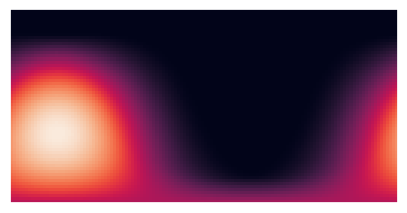

In [34]:
# get a item from the train_dataset
surface_t, upper_air_t, surface_t_1, upper_air_t_1, varying_boundary_data, times = train_dataset[0]

# load the 10 first items and concatenate them along a new dimension
n = 3
for i in trange(n):
    surface_t, upper_air_t, surface_t_1, upper_air_t_1, varying_boundary_data, times = train_dataset[i]
    if i == 0:
        surface_t_all = surface_t.unsqueeze(0)
        upper_air_t_all = upper_air_t.unsqueeze(0)
        surface_t_1_all = surface_t_1.unsqueeze(0)
        upper_air_t_1_all = upper_air_t_1.unsqueeze(0)
        varying_boundary_data_all = varying_boundary_data.unsqueeze(0)
    else:
        surface_t_all = torch.cat((surface_t_all, surface_t.unsqueeze(0)), dim=0)
        upper_air_t_all = torch.cat((upper_air_t_all, upper_air_t.unsqueeze(0)), dim=0)
        surface_t_1_all = torch.cat((surface_t_1_all, surface_t_1.unsqueeze(0)), dim=0)
        upper_air_t_1_all = torch.cat((upper_air_t_1_all, upper_air_t_1.unsqueeze(0)), dim=0)
        varying_boundary_data_all = torch.cat((varying_boundary_data_all, varying_boundary_data.unsqueeze(0)), dim=0)
        

constant_boundary_data = train_dataset.constant_boundary_data.unsqueeze(0) * torch.ones(n, 1, 1, 1)
# show the varying_boundary_data on a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt


# plot the varying_boundary_data
fig = plt.figure(figsize=(5, 4))
# the whole world as dimension 64x128
ax = plt.axes(projection=ccrs.PlateCarree())
# show the varying_boundary_data[1,:,:]
im = ax.imshow(varying_boundary_data[params.varying_boundary_variables.index('rsdt')])

In [35]:
from networks.pangu import PanguModel_Plasim
import importlib as imp
import networks
imp.reload(networks.pangu)
from networks.pangu import PanguModel_Plasim

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PanguModel_Plasim(params).to(device)
# model(input_surface, constant_boundary_data, varying_boundary_data, input_upper_air)


EST_input_resolution (7, 32, 64)


In [40]:
model.EST_input_resolution.sel

(7, 32, 64)

In [37]:
# model(input_surface, constant_boundary_data, varying_boundary_data, input_upper_air)
val_output_surface, val_output_upper_air  = model(surface_t_all, constant_boundary_data, varying_boundary_data_all, upper_air_t_all)

In [38]:
val_output_surface.shape, val_output_upper_air.shape

(torch.Size([3, 2, 64, 128]), torch.Size([3, 5, 10, 64, 128]))

In [39]:
model.downscale_resolution
self = model
downscale_resolution = (self.patchembed3d.output_size[0]+1,
                                (self.patchembed2d.output_size[0] - self.patchembed2d.output_size[0] % params.updown_scale_factor) \
                                // params.updown_scale_factor + self.patchembed2d.output_size[0] % params.updown_scale_factor,
                                (self.patchembed2d.output_size[1] - self.patchembed2d.output_size[1] % params.updown_scale_factor) \
                                // params.updown_scale_factor + self.patchembed2d.output_size[1] % params.updown_scale_factor)

In [54]:
downscale_resolution

(6, 16, 32)

In [18]:
self.EST_input_resolution

NameError: name 'self' is not defined

In [45]:
self.patchembed2d.output_size

(32, 64)

In [83]:
varying_boundary_data.shape

torch.Size([3, 64, 128])

In [5]:
import warnings
# import join
from os.path import join

data_dir = params.data_dir
def _load_boundary_data(self, initial = True):
        if initial:
            print('Loading varying boundary from %s' % join(params.data_dir, params.boundary_dir))
            boundary_files = [join(params.data_dir, params.boundary_dir, f) for f in os.listdir(join(params.data_dir, self.boundary_dir)) \
                                    if any(var in f for var in self.varying_boundary_variables)]
            # if 'rsdt' is present, it should be the last file
            boundary_leap_files = [file for file in boundary_files if '_leap' in os.path.basename(file)]
            boundary_noleap_files = [file for file in boundary_files if '_leap' not in os.path.basename(file)]
            print(boundary_noleap_files)
            # put files that finish with 'rsdt.nc' at last position
            boundary_leap_files = sorted(boundary_leap_files, key=lambda x: 'rsdt_leap.nc' in x)
            boundary_noleap_files = sorted(boundary_noleap_files, key=lambda x: 'rsdt.nc' in x)
            print(boundary_noleap_files)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore",
                                    message='^.*Unable to decode time axis into full numpy.datetime64 objects.*$')
            boundary_ds_leap = xr.open_mfdataset(boundary_leap_files, chunks={'time': 1}, engine='netcdf4', parallel=True, decode_cf=False)
            boundary_ds_noleap = xr.open_mfdataset(boundary_noleap_files, chunks={'time': 1}, engine='netcdf4', parallel=True, decode_cf=False)
            boundary_ds_leap = boundary_ds_leap[[var for var in boundary_ds_leap.data_vars if var != 'rsdt'] + ['rsdt']]
            boundary_ds_noleap = boundary_ds_noleap[[var for var in boundary_ds_noleap.data_vars if var != 'rsdt'] + ['rsdt']]
        return [boundary_ds_noleap, boundary_ds_leap]

In [6]:
data1, data2 = _load_boundary_data(params, initial = True)

Loading varying boundary from /glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars
['/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/rsdt.nc', '/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/sic.nc', '/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/sst.nc']
['/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/sic.nc', '/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/sst.nc', '/glade/derecho/scratch/awikner/PLASIM/data/2000_year_sims_new/train_val_test_data/boundary_vars/rsdt.nc']


In [8]:
for var in data1:
    print(var)

sic
sst
rsdt


In [11]:
params.varying_boundary_variables

['sst', 'rsdt', 'sic']

In [10]:
for var in self.varying_boundary_variables:
        varying_boundary_tensor = torch.from_numpy(
        data1[var].values).to(torch.float32)

NameError: name 'self' is not defined

In [ ]:
# from tqdm import tqdm
# import time


# nb = len(train_data_loader)
# pbar = enumerate(train_data_loader, 0)
# pbar = tqdm(pbar, total=nb, bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')

# running_results = {"batch_sizes": 0, "loss": 0}

# # if params.diagnostic_logs:
# #     diagnostic_logs = {}

# # For each epoch, we iterate from 1979 to 2017
# for i, data in pbar:
#     # Load weather data at time t as the input; load weather data at time t+1/3/6/24 as the output
#     # Note the data need to be randomly shuffled
#     # Note the input and target need to be normalized, see Inference() for details
    
#     # self.iters += 1
#     # adjust_LR(optimizer, params, iters)
#     data_start = time.time()
#     #inp_sfc, inp_pl, tar_sfc, tar_pl = map(lambda x: x.to(self.device, dtype=torch.float32), data)
#     input_surface, input_upper_air, target_surface, target_upper_air, varying_boundary_data, index_info = data
#     if i==0:
#         print(input_surface.shape, input_upper_air.shape, target_surface.shape, target_upper_air.shape, varying_boundary_data.shape)
#     if i > 0:
#         break

In [ ]:
# # save input_surface, input_upper_air, target_surface, target_upper_air, varying_boundary_data, index_info
# dir2save = "/glade/work/alancelin/PanguWeather/tests/"
# torch.save(input_surface, dir2save + "input_surface.pt")
# torch.save(input_upper_air, dir2save + "input_upper_air.pt")
# torch.save(target_surface, dir2save + "target_surface.pt")
# torch.save(target_upper_air, dir2save + "target_upper_air.pt")
# torch.save(varying_boundary_data, dir2save + "varying_boundary_data.pt")
# torch.save(index_info, dir2save + "index_info.pt")

In [ ]:
self.params.diagnostic_logs

In [40]:
# print architecture summary of the model
from torchsummary import summary

input_size = preds.isel(time=0).to_array().shape
summary(model, input_size=[input_size, (2,3), (35,2), (6,2)])

RuntimeError: Tensors must have same number of dimensions: got 5 and 4

In [34]:
input_size = preds.isel(time=0).to_array().shape[1:]
input_size

(64, 128, 13)